In [1]:
from firedrake import *
import matplotlib.pyplot as plt
import numpy as np
from math import ceil
from firedrake.petsc import PETSc
import petsc4py
from time import perf_counter

firedrake:WARNING OMP_NUM_THREADS is not set or is set to a value greater than 1, we suggest setting OMP_NUM_THREADS=1 to improve performance



# Ex.1 Stokes: Schur-complement method.

Let's consider the usual cavity problem

\begin{equation*}
\begin{cases}
- \Delta \boldsymbol{u} + \nabla  p  = \boldsymbol{0} & {\rm in} \ \Omega=(0,1)^2, \\
{\rm div}\,\boldsymbol{u} = 0 & {\rm in} \ \Omega, \\
\boldsymbol{u} = \boldsymbol{g}_\text{D} & {\rm on} \ \Gamma_4 = (0,1)\times\{4\},\\
\boldsymbol{u} = \boldsymbol{0} & {\rm on} \ \partial\Omega\setminus\Gamma_4,
\end{cases}
\end{equation*}

with $\boldsymbol{g}_\text{D} = 1\boldsymbol{i}$.

We also impose the boundary conditions weakly, that means

$$
u = g + \varepsilon (\nabla u - p)n \implies (\nabla u - p)n  = \frac{1}{\varepsilon} (u-g).
$$

This way we reformulate the Dirichlet problem using Neumann-type structure. In the weak formulation we will have a mass term for the part regarding $u$ on the left hand side, while on the right hand side we will have a forcing term depending on $g$; both of them will be integrals on $\Gamma_D$.

In [2]:
# We use the GLOBAL PETSc options, stored in the following global variable.
# This variable is modified by Firedrake when we set the solver parameters
# by, e.g.,     LinearVariationalSolver(..., solver_parameters=...)
petsc_options = PETSc.Options()

### 1. Assemble the matrices defining the problem

In [3]:
def schur_assemble(N):
    """
    Assemble the monolithic matrix and the rhs of the Stokes problem, and define a solver for the A block (needed to assemble the rhs of the Schur system and to reconstruct velocity).

    Input:   N  number of elements in each direction (mesh is NxN)
    Output:  V, Q  FE spaces for velocity and pressure
             A, asB, Bt  blocks of the monolithic matrix
             F  rhs of the monolithic system
             ksp_A  solver for the A block
    """
    # Mesh, FE spaces (separate, not mixed), and trial and test functions.
    mesh = UnitSquareMesh(N, N, 'crossed')
    V = VectorFunctionSpace(mesh, "P", 2)
    Q = FunctionSpace(mesh, "P", 1)
    u = TrialFunction(V)
    p = TrialFunction(Q)
    v = TestFunction(V)
    q = TestFunction(Q)

    # Variational forms with the penalty method for Dirichlet boundary conditions.
    eps = 1e-20
    nu = 1.0
    a = Constant(nu) * inner(grad(u), grad(v)) *dx + 1/eps*(inner(u, v)*ds)
    minusb = q * div(u) * dx
    bt = - div(v) * p * dx
    L = inner(Constant((0.0, 0.0)), v)*dx + 1/eps*(inner(Constant((1.0, 0.0)), v)*ds(4)) + 1/eps*(inner(Constant((0.0, 0.0)), v)*ds((1, 2, 3)))

    # Assemble monolithic system
    # "MAT=assemble(FORM)" yields a Firedrake matrix. To extract its PETSc representation, we use "MAT.M.handle".
    A = assemble(a).M.handle
    minusB = assemble(minusb).M.handle
    Bt = assemble(bt).M.handle
    F = assemble(L)

    # Define a solver for A: needed to assemble the rhs of the Schur system and to reconstruct velocity.
    # We modify and use the global PETSc options to tell PETSc how this solver should be set up.
    ksp_A = PETSc.KSP().create()
    ksp_A.setOperators(A)
    petsc_options['ksp_type'] = 'gmres'
    petsc_options['pc_type'] = 'ilu'
    ksp_A.setFromOptions()
    ksp_A.setUp()

    return V, Q, A, minusB, Bt, F, ksp_A

### 2. Define classes for Schur complement and M-based preconditioner.

In [5]:
def define_schur_solver(A, asB, Bt, pc_S_form):
    """
    Define the Schur complement S=-(asB*A^-1*Bt) and a solver for it, with a suitable preconditioner.
    
    Input:   A, asB, Bt  blocks of the monolithic matrix
             pc_S_form   preconditioner for the Schur complement S
    Output:  S           the Schur complement S=-(asB*A^-1*Bt)
    Notice: asB can be either B or -B: the resulting S will have a different sign
    """
    print('\nSCHUR SOLVER')
    print('------------')
    if (asB - PETSc.Mat().createTranspose(Bt)).norm() < 1e-15:
        print('Block-symmetric formulation', end='')
        print(r"""         ┌      ┐
        │ A  Bᵀ│ => U = A⁻¹(F - BᵀP)
        │ B  0 │    S = -B A⁻¹ Bᵀ, SP = B A⁻¹ F
        └      ┘""")
    elif (asB + PETSc.Mat().createTranspose(Bt)).norm() < 1e-15:
        print('Block-skew-symmetric formulation')
        print(r"""        ┌      ┐
        │ A  Bᵀ│ => U = A⁻¹(F - BᵀP)
        │-B  0 │    S = B A⁻¹ Bᵀ, SP = -B A⁻¹ F
        └      ┘""")
    else:
        print('WARNING - Re-check def of asB, Bt', (asB - PETSc.Mat().createTranspose(Bt)).norm(), (asB + PETSc.Mat().createTranspose(Bt)).norm())
    print('Sizes')
    print('-> A  :', A.size)
    print('-> Bt :', Bt.size)
    print('-> asB:', asB.size)

    # Define Schur complement S.
    # Syntax: S = PETSc.Mat().createSchurComplement(A00, pc_A00, A01, A10, A11)
    # NB1: does not actually perform "A^-1": it sets up the system so that it can represent the application of S
    # NB2: as a preconditioner for A within the definition of S, we use A itself  <->  direct solver for A^-1 in the definition
    # NB3: the problem we are interested in has A11=0 -> use None
    S = PETSc.Mat().createSchurComplement(A, A, Bt, asB, None)

    # ksp_A sets options also on A.
    # If different options ought to be set in A to be used within S,
    # they should be set here, through S.
    tmp_ksp = petsc_options['ksp_type']
    tmp_pc = petsc_options['pc_type']
    petsc_options['ksp_type'] = 'preonly'
    petsc_options['pc_type'] = 'lu'
    S.setFromOptions()
    petsc_options['ksp_type'] = tmp_ksp
    petsc_options['pc_type'] = tmp_pc

    # Setup the preconditioner
    ones_vec = PETSc.Vec().createWithArray(np.ones(S.size[0])) # useful below...

    # based on the input pc_S_form
    MM = assemble(pc_S_form).M.handle

    # lumped pressure mass matrix
    lumped_vec = MM.createVecRight()
    MM.mult(ones_vec, lumped_vec)
    pc_S_mat = PETSc.Mat().createDiagonal(lumped_vec)

    # # Diagonal of the pressure mass matrix
    # diag_vec = MM.createVecRight()
    # MM.getDiagonal(diag_vec)
    # pc_S_mat = PETSc.Mat().createDiagonal(diag_vec)

    # # pressure mass matrix
    # pc_S_mat = MM

    # # no preconditioner -> identity matrix
    # pc_S_mat = PETSc.Mat().createDiagonal(ones_vec)


    # We know that S "has a nullspace" spanned by constant functions
    # (or at least that its eigenvalue along this space is on the order of eps).
    # Skipping this setting actually provides the same results in this specific exercise,
    # yet it is better to keep aware of this possible issue.
    nullspace = PETSc.NullSpace().create(constant=True)
    S.setNullSpace(nullspace) # set nullspace of S before passing it to ksp_S

    # Define a solver for the Schur complement, with a suitable preconditioner.
    # Use the global variable petsc_options to setup the solver.
    ksp_S = PETSc.KSP().create()
    ksp_S.setOperators(S, pc_S_mat)
    ksp_S.setOptionsPrefix('schur_')
    petsc_options['schur_ksp_type'] = 'cg'
    petsc_options['schur_pc_type'] = 'mat'
    ksp_S.setFromOptions()
    ksp_S.setUp()

    return S, ksp_S

### 3. Solve Stokes cavity problem.

In [6]:
def solve_schur(V, Q, ksp_A, asB, Bt, F, ksp_S):
    """
    Solve the Stokes problem using the Schur complement approach.

    Input:   V, Q  FE spaces for velocity and pressure
             ksp_A  solver for the A block
             asB, Bt  blocks of the monolithic matrix
             F  rhs of the monolithic system
             ksp_S  solver for the Schur complement S
    Output:  uh, ph  solutions for velocity and pressure
    Notice: the sign of S should be in accordance with the sign of asB (which can be either B or -B).
    """
    uh = Function(V)
    ph = Function(Q)
    tmp_u_fun = Function(V)
    tmp_p_fun = Function(Q)
    rhs_p_fun = Function(Q)

    # Extract the dof vectors as PETSc.Vec and give them aliases.
    # Temporary vectors are in read/write mode,
    # while momentum rhs is in read-only mode.
    with uh.dat.vec_wo as vecU,\
        ph.dat.vec_wo as vecP,\
        F.dat.vec_ro as vecF,\
        tmp_u_fun.dat.vec_wo as tmp_u,\
        tmp_p_fun.dat.vec_wo as tmp_p,\
        rhs_p_fun.dat.vec_wo as rhs_p:    # this is chi

        print("SOLVING WITH PRESSURE MATRIX METHOD", flush=True)
        print("-----------------------------------")
        # RIGHT HAND SIDE
        # rhs_p = -asB*(A^{-1}*F)
        print("##### Assembling RHS", flush=True)
        # solve A*tmp_u = - F
        # see https://petsc.org/release/petsc4py/reference/petsc4py.PETSc.KSP.html#petsc4py.PETSc.KSP.solve
        ksp_A.solve(-vecF, tmp_u)  
        # compute rhs_p = asB*tmp_u
        rhs_p = asB * tmp_u        
        print("##### Completed Assembling RHS \t\t\t(" + str(ksp_A.getIterationNumber()) + " iter for A^-1)", flush=True)

        # SOLVE THE SCHUR SYSTEM
        # solve S*P = rhs_p and store it into the dof array of ph
        print("##### Solving Schur complement", flush=True)
        start_time = perf_counter()
        ksp_S.solve(rhs_p, vecP)
        elapsed_time = perf_counter() - start_time
        print("##### Completed Solving Schur complement \t(" + str(ksp_S.getIterationNumber()) + " iter for S^-1, in " + str(elapsed_time) + "s)", flush=True)

        # RECONSTRUCT VELOCITY
        # compute U = A^{-1}*(F-asB'*P) and store it into the dof array of uh
        print("##### Reconstructing velocity", flush=True)
        # compute rhs_u = F - asB'*P
        tmp_u = vecF - Bt * vecP
        # solve A*U = rhs_u
        ksp_A.solve(tmp_u, vecU)
        print("##### Completed velocity reconstruction \t(" + str(ksp_A.getIterationNumber()) + " iter for A^-1)", flush=True)

    return uh, ph

In [7]:
# Set verbose to True for detailed logging of ksp's.
verbose = False
if verbose:
    petsc_options['ksp_view'] = ''
    petsc_options['ksp_monitor'] = ''
    # petsc_options['ksp_monitor_true_residual'] = ''   # too much information: activate it only when necessary
    petsc_options['schur_ksp_view'] = ''
    petsc_options['schur_ksp_monitor'] = ''
    # petsc_options['schur_ksp_monitor_true_residual'] = ''   # too much information: activate it only when necessary
else:
    del petsc_options['ksp_view']
    del petsc_options['ksp_monitor']
    del petsc_options['ksp_monitor_true_residual']
    del petsc_options['schur_ksp_view']
    del petsc_options['schur_ksp_monitor']
    del petsc_options['schur_ksp_monitor_true_residual']

V, Q, A, minusB, Bt, F, ksp_A = schur_assemble(10)

nu = 1.0
p = TrialFunction(Q)
q = TestFunction(Q)
pc_form = Constant(1/nu) * q * p * dx
S, ksp_S = define_schur_solver(A, minusB, Bt, pc_form)

print("")
print("-"*50)
# Print all set options.
petsc_options.view()
print("-"*50)
print("")

# Solve problem
uh, ph = solve_schur(V, Q, ksp_A, minusB, Bt, F, ksp_S)


SCHUR SOLVER
------------
Block-skew-symmetric formulation
        ┌      ┐
        │ A  Bᵀ│ => U = A⁻¹(F - BᵀP)
        │-B  0 │    S = B A⁻¹ Bᵀ, SP = -B A⁻¹ F
        └      ┘
Sizes
-> A  : (882, 882)
-> Bt : (882, 121)
-> asB: (121, 882)

--------------------------------------------------
#PETSc Option Table entries:
--f=/run/user/1000/jupyter/runtime/kernel-v31a49d797ca46c71e6fd26698104fa9034833f4a4.json # (source: command line)
-ksp_type gmres # (source: code)
-pc_type ilu # (source: code)
-schur_ksp_type cg # (source: code)
-schur_pc_type mat # (source: code)
#End of PETSc Option Table entries
--------------------------------------------------

SOLVING WITH PRESSURE MATRIX METHOD
-----------------------------------
##### Assembling RHS
##### Completed Assembling RHS 			(11 iter for A^-1)
##### Solving Schur complement
##### Completed Solving Schur complement 	(18 iter for S^-1, in 0.0035316100002091844s)
##### Reconstructing velocity
##### Completed velocity reconstruction 	(12 

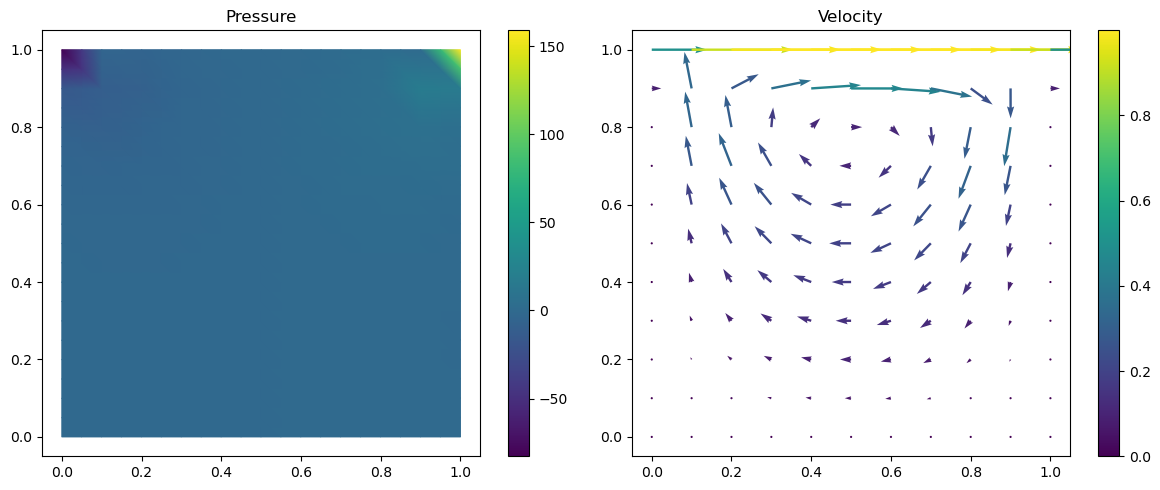

In [10]:
# Plot numerical solutions
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

col0 = tripcolor(ph, axes=ax[0])
fig.colorbar(col0, ax=ax[0])
ax[0].set_title('Pressure')

col1 = quiver(uh, axes=ax[1])
fig.colorbar(col1, ax=ax[1])
ax[1].set_title('Velocity')

plt.tight_layout()

# Ex.2: Stokes: solve time dependent problem

Let's consider the time dependent cavity problem

\begin{equation*}
\begin{cases}
\frac{\partial\boldsymbol{u}}{\partial t} - \Delta \boldsymbol{u} + \nabla  p  = \boldsymbol{0} & {\rm in} \ \Omega=(0,1)^2
\quad\forall t\in(0,1), \\
{\rm div}\,\boldsymbol{u} = 0 & {\rm in} \ \Omega
\quad\forall t\in(0,1), \\
\boldsymbol{u} = \boldsymbol{g}_\text{D} & {\rm on} \ \Gamma_4 = (0,1)\times\{4\}
\quad\forall t\in(0,1), \\
\boldsymbol{u} = \boldsymbol{0} & {\rm on} \ \partial\Omega\setminus\Gamma_4
\quad\forall t\in(0,1), \\
\boldsymbol{u} = \boldsymbol{0} & {\rm in} \ \Omega,
\quad{\rm for} \ t=0,
\end{cases}
\end{equation*}

with $\boldsymbol{g}_\text{D}(t,\boldsymbol{x}) = t\boldsymbol{i}$.


For the definition of the problem, variational forms, matrices, preconditioners, we use what has been already computed in Exercise 1 - point 4.

In [11]:
def schur_assemble_time(N, dt):
    """
    Assemble the monolithic matrix and the rhs of the Stokes problem, and define a solver for the A block (needed to assemble the rhs of the Schur system and to reconstruct velocity).
    Input:   N  number of elements in each direction (mesh is NxN)
             dt time step size (not actually used here, but useful to keep track of the time step size for which the assembly time is measured)
    Output:  V, Q  FE spaces for velocity and pressure
             A, M, asB, Bt  blocks of the monolithic matrix
             F  rhs of the monolithic system
             ksp_MA  solver for the M+A block
    Notice: The algebraic system at each time step is (M+A)*U + B'*P = M*Uold + F, -B*U = 0.
    """
    # Mesh, FE spaces (separate, not mixed), and trial and test functions.
    V, Q, A, minusB, Bt, F, ksp_A = schur_assemble(N)
    u = TrialFunction(V)
    v = TestFunction(V)
    M = assemble(Constant(1.0/dt) * inner(u, v) * dx).M.handle
    
    # Note: since we are using the penalty method to enforce Dirichlet BCs, we do not need to apply BCs to the matrix M.

    # Define a new KSP solver associated to (M+A).
    ksp_MA = PETSc.KSP().create()
    ksp_MA.setType('preonly')   # direct solver
    ksp_MA.pc.setType('lu')
    ksp_MA.setOperators(M+A)
    ksp_MA.setFromOptions()
    ksp_MA.setUp()

    return V, Q, M, A, minusB, Bt, F, ksp_MA

In [12]:
# Time parameters and initial condition.
t0 = 0
T = 0.2
dt = 0.005
u0 = Function(V)    # We need the old solution to be a Function, since we need its dof vector to proceed algebraically
u0.interpolate(Constant((0., 0.)))

# Create the Schur complement.
V, Q, M, A, minusB, Bt, F, ksp_MA = schur_assemble_time(10, dt)

p = TrialFunction(Q)
q = TestFunction(Q)
pc_form = p * q * dx
S, ksp_S = define_schur_solver(A, minusB, Bt, pc_form)

# Solve time-dependent problem
print("")
print("-"*50)
print("SOLVING TIME-DEPENDENT PROBLEM")
print("-"*50)

print(f't = {t0:.3f} :  ||u||L2 = {norm(u0, "L2"):.4f}')
print("-"*50)

# store solutions
times = []
vel_solutions = []
pres_solutions = []

tmp_u_fun = Function(V)
rhs_u_fun = Function(V)
for t in dt+np.arange(t0, T, dt):
    with u0.dat.vec_wo as vecUold,\
        F.dat.vec_ro as vecF,\
        tmp_u_fun.dat.vec_wo as tmp_u,\
        rhs_u_fun.dat.vec_wo as rhs:
        # Assemble the current rhs of the momentum equation and store it in rhs
        vecF.copy(tmp_u)                # NB NOT tmp_u = vecF (would perform only shallow copy, i.e. reference to same object)
        tmp_u *= t
        M.multAdd(vecUold, tmp_u, rhs)  # rhs = M*vecUold + tmp_u
    print(f"Step t = {t:.3f}")
    # Advance in time: solve the problem with M+A in place of A
    print("")
    uh, ph = solve_schur(V, Q, ksp_MA, minusB, Bt, rhs_u_fun, ksp_S)
    print("")
    print(f't = {t:.3f} :  ||u||L2 = {norm(uh, "L2"):.4f}')
    print('-'*50)

    # Save snapshots
    times.append(t)
    
    u_save = Function(V)
    p_save = Function(Q)
    u_save.assign(uh)
    p_save.assign(ph)

    vel_solutions.append(u_save)
    pres_solutions.append(p_save)

    u0 = uh # update the old solution

# -------------------------
# Create animation
# -------------------------

from matplotlib.animation import FuncAnimation
import matplotlib.colors as colors

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

pmin = min(p.dat.data.min() for p in pres_solutions)
pmax = max(p.dat.data.max() for p in pres_solutions)
vmax = max(np.sqrt((u.dat.data**2).sum(axis=1)).max() for u in vel_solutions)
normalization = colors.Normalize(vmin=0, vmax=vmax)

# initial frame
pre0 = tripcolor(pres_solutions[0],axes=ax1,vmin=pmin,vmax=pmax)
cbar1 = fig.colorbar(pre0, ax=ax1)
vel0 = quiver(vel_solutions[0], axes=ax2, scale=vmax, norm=normalization)
cbar2 = fig.colorbar(vel0, ax=ax2)

def update(i):
    # safely remove previous artists
    for c in ax1.collections[:]:
        c.remove()
    for c in ax2.collections[:]:
        c.remove()

    pre = tripcolor(pres_solutions[i],axes=ax1,vmin=pmin,vmax=pmax)
    vel = quiver(vel_solutions[i], axes=ax2, scale=5*vmax, norm=normalization)

    ax1.set_title(f"Pressure t={times[i]:.3f}")
    ax2.set_title(f"Velocity t={times[i]:.3f}")

    return []

anim = FuncAnimation(
    fig,
    update,
    frames=len(times),
    interval=200
)

plt.close()



SCHUR SOLVER
------------
Block-skew-symmetric formulation
        ┌      ┐
        │ A  Bᵀ│ => U = A⁻¹(F - BᵀP)
        │-B  0 │    S = B A⁻¹ Bᵀ, SP = -B A⁻¹ F
        └      ┘
Sizes
-> A  : (882, 882)
-> Bt : (882, 121)
-> asB: (121, 882)

--------------------------------------------------
SOLVING TIME-DEPENDENT PROBLEM
--------------------------------------------------
t = 0.000 :  ||u||L2 = 0.0000
--------------------------------------------------
Step t = 0.005

SOLVING WITH PRESSURE MATRIX METHOD
-----------------------------------
##### Assembling RHS
##### Completed Assembling RHS 			(5 iter for A^-1)
##### Solving Schur complement
##### Completed Solving Schur complement 	(18 iter for S^-1, in 0.003144780000184255s)
##### Reconstructing velocity
##### Completed velocity reconstruction 	(5 iter for A^-1)

t = 0.005 :  ||u||L2 = 0.0008
--------------------------------------------------
Step t = 0.010

SOLVING WITH PRESSURE MATRIX METHOD
-----------------------------------
#####

In [13]:
from IPython.display import HTML
HTML(anim.to_jshtml())